In [2]:

# Import Required Libraries


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
import pandas as pd

# Load the specific dataset tab from your Excel file
df = pd.read_excel("PCOS_data_without_infertility.xlsx", sheet_name="Full_new")

# View the first few rows to verify it loaded correctly
df.head()


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,NaN,36,30,NaN,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,NaN,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,NaN,38,32,NaN,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,NaN,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,NaN,40,36,NaN,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,NaN,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,NaN,42,36,NaN,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,NaN,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,NaN,37,30,NaN,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [5]:
import pandas as pd

# Assuming PCOS_data_without_infertility.xlsx is uploaded to the Colab environment's current directory
df = pd.read_excel('PCOS_data_without_infertility.xlsx', sheet_name='Full_new')

print('Dataset loaded successfully!')

Dataset loaded successfully!


In [6]:
# Display First 5 Rows

df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,NaN,36,30,NaN,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,NaN,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,NaN,38,32,NaN,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,NaN,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,NaN,40,36,NaN,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,NaN,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,NaN,42,36,NaN,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,NaN,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,NaN,37,30,NaN,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 541
Columns : 45


In [8]:
print(df.columns.tolist())

['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']


In [9]:
# Remove leading and trailing spaces from column names

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']


In [10]:
# Remove unwanted empty column

if 'Unnamed: 44' in df.columns:
    df.drop(columns=['Unnamed: 44'], inplace=True)

print(df.shape)

(541, 44)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3   Age (yrs)               541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     242 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl. No,541.0,271.000000,156.317519,1.000,136.000,271.000,406.000,541.000
Patient File No.,541.0,271.000000,156.317519,1.000,136.000,271.000,406.000,541.000
PCOS (Y/N),541.0,0.327172,0.469615,0.000,0.000,0.000,1.000,1.000
Age (yrs),541.0,31.430684,5.411006,20.000,28.000,31.000,35.000,48.000
Weight (Kg),541.0,59.637153,11.028287,31.000,52.000,59.000,65.000,108.000
Height(Cm),541.0,156.484835,6.033545,137.000,152.000,156.000,160.000,180.000
BMI,242.0,23.929752,3.663177,15.100,21.900,24.000,25.975,38.900
Blood Group,541.0,13.802218,1.840812,11.000,13.000,14.000,15.000,18.000
Pulse rate(bpm),541.0,73.247689,4.430285,13.000,72.000,72.000,74.000,82.000
RR (breaths/min),541.0,19.243993,1.688629,16.000,18.000,18.000,20.000,28.000


In [13]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
BMI,299
Marraige Status (Yrs),1
FSH/LH,532
Waist:Hip Ratio,532
Fast food (Y/N),1


In [14]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns = numeric_columns.drop('PCOS (Y/N)')

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [15]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [16]:
# Remove duplicate rows if any

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (541, 44)


In [17]:
print("Final Dataset Shape :", df.shape)
print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())

Final Dataset Shape : (541, 44)
Missing Values : 0
Duplicate Rows : 0


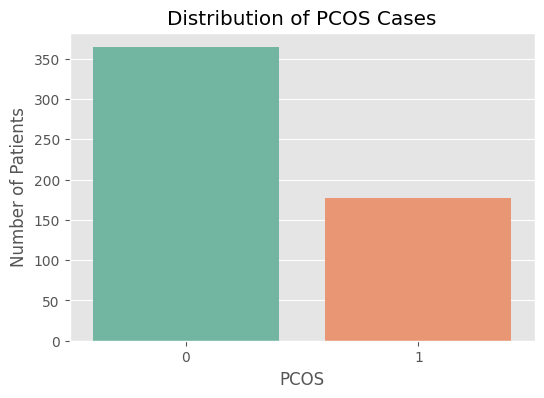

In [18]:
#Exploratoy Data Analysis
plt.figure(figsize=(6,4))

sns.countplot(x='PCOS (Y/N)', data=df, palette='Set2')

plt.title("Distribution of PCOS Cases")
plt.xlabel("PCOS")
plt.ylabel("Number of Patients")

plt.show()

In [19]:
pcos_percent = df['PCOS (Y/N)'].value_counts(normalize=True) * 100

print(pcos_percent)

PCOS (Y/N)
0    67.28281
1    32.71719
Name: proportion, dtype: float64


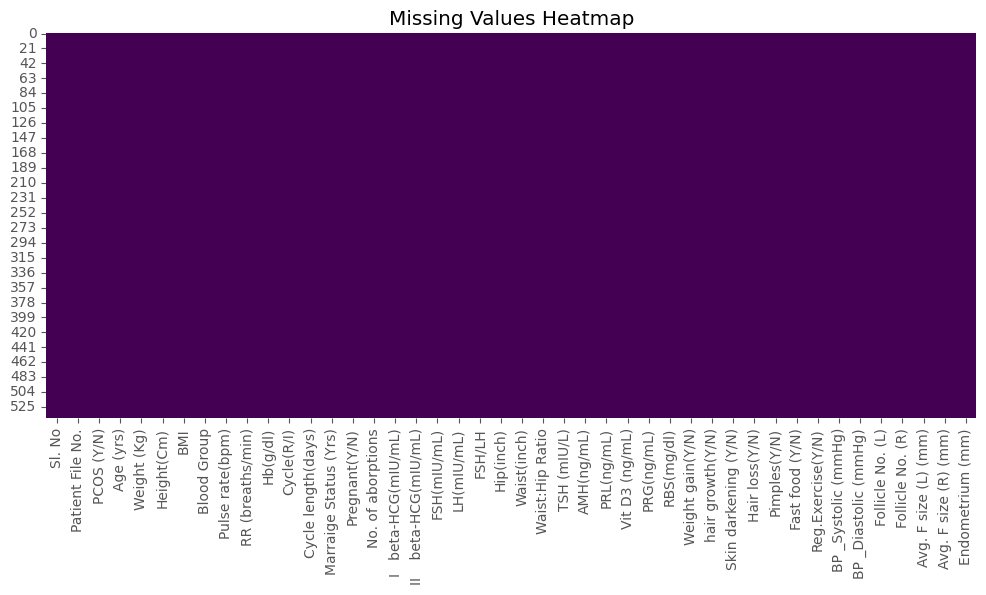

In [20]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

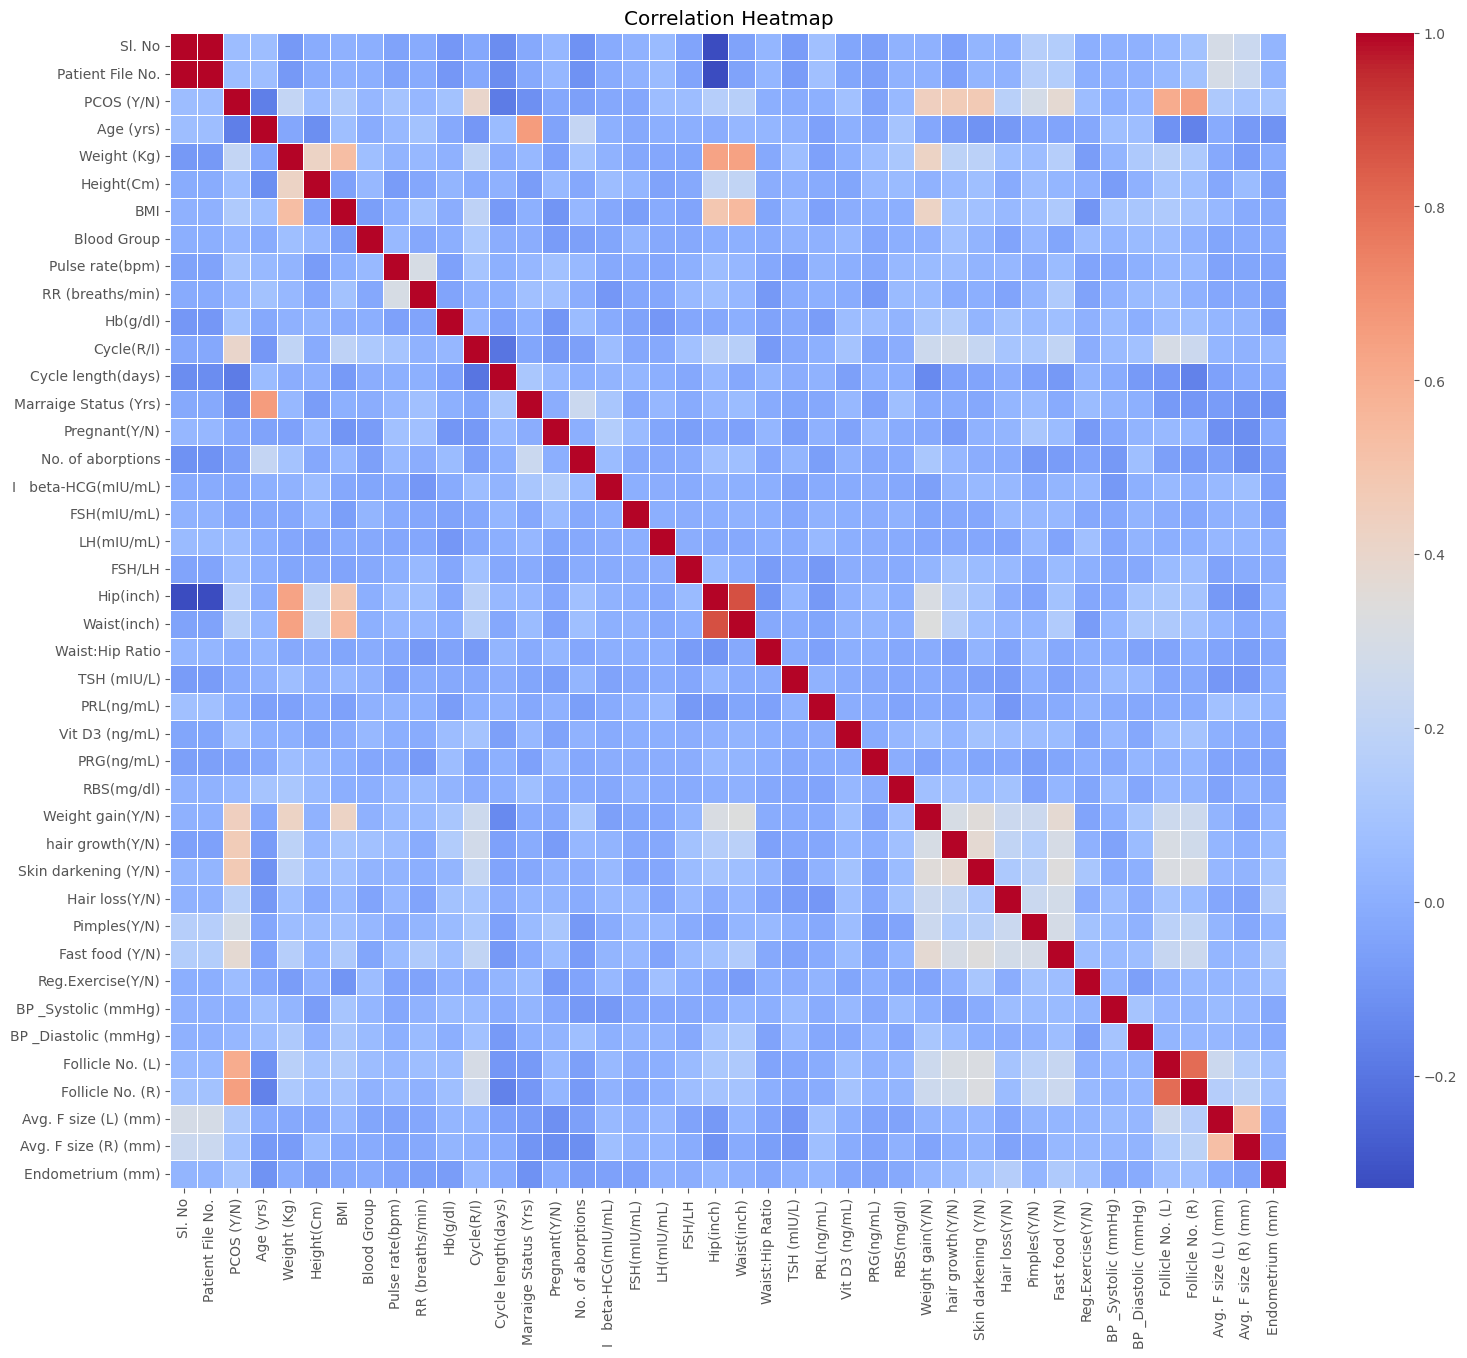

In [21]:
plt.figure(figsize=(18,15))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

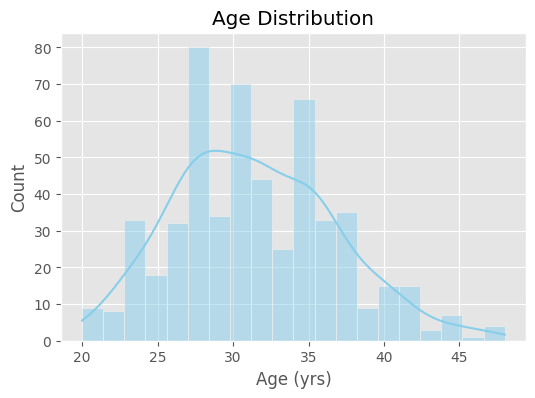

In [22]:
plt.figure(figsize=(6,4))

sns.histplot(df['Age (yrs)'],
             bins=20,
             kde=True,
             color='skyblue')

plt.title("Age Distribution")

plt.show()

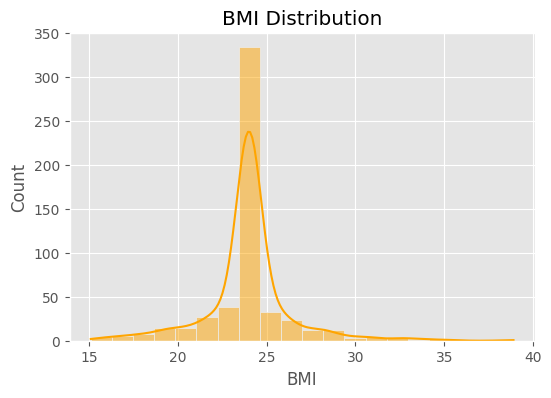

In [23]:
plt.figure(figsize=(6,4))

sns.histplot(df['BMI'],
             bins=20,
             kde=True,
             color='orange')

plt.title("BMI Distribution")

plt.show()

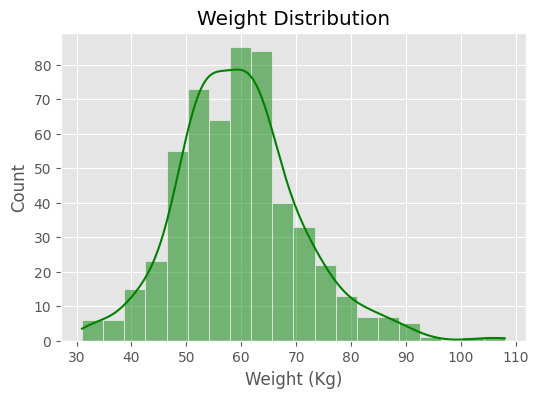

In [24]:
plt.figure(figsize=(6,4))

sns.histplot(df['Weight (Kg)'],
             bins=20,
             kde=True,
             color='green')

plt.title("Weight Distribution")

plt.show()

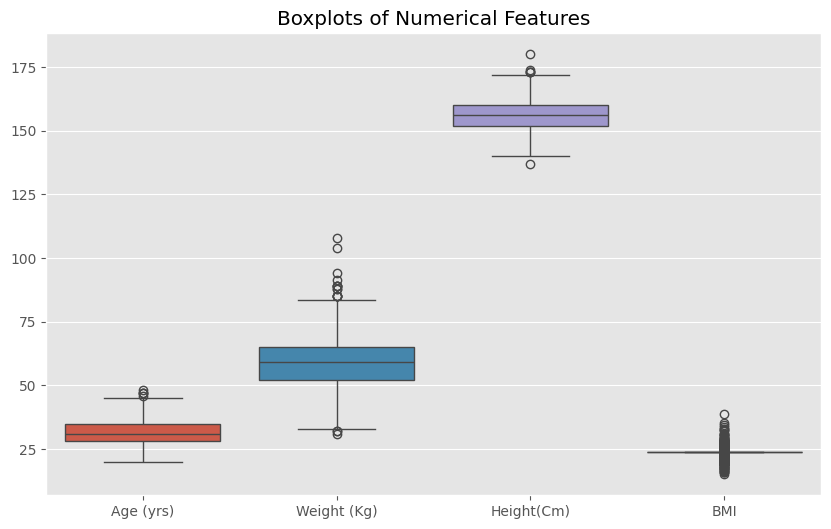

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['Age (yrs)',
                     'Weight (Kg)',
                     'Height(Cm)',
                     'BMI']])

plt.title("Boxplots of Numerical Features")

plt.show()

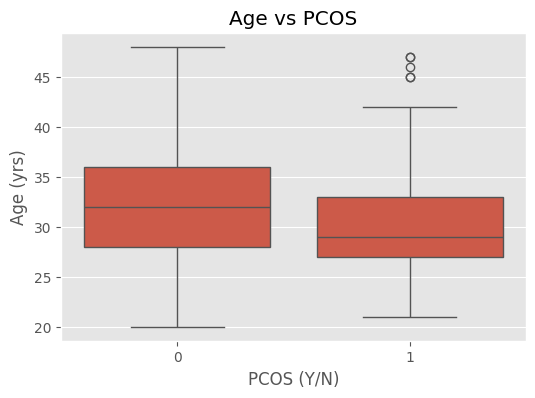

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(x='PCOS (Y/N)',
            y='Age (yrs)',
            data=df)

plt.title("Age vs PCOS")

plt.show()

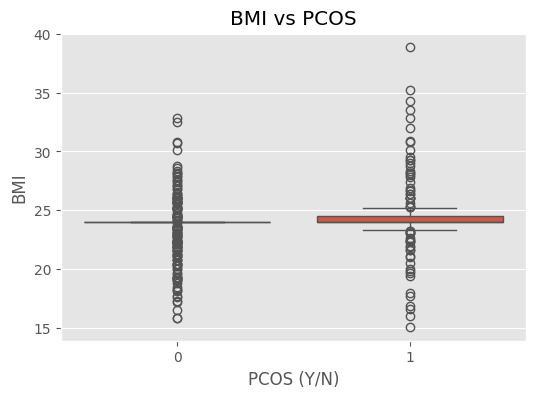

In [27]:
plt.figure(figsize=(6,4))

sns.boxplot(x='PCOS (Y/N)',
            y='BMI',
            data=df)

plt.title("BMI vs PCOS")

plt.show()

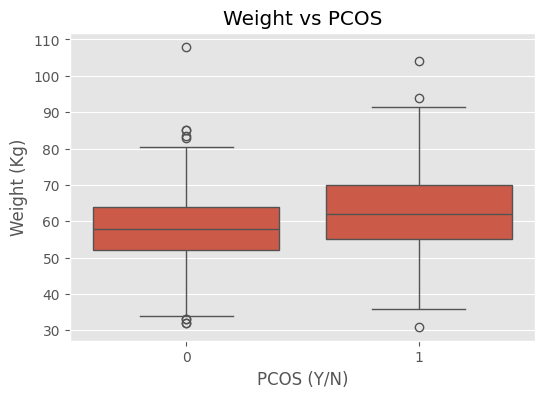

In [28]:
plt.figure(figsize=(6,4))

sns.boxplot(x='PCOS (Y/N)',
            y='Weight (Kg)',
            data=df)

plt.title("Weight vs PCOS")

plt.show()

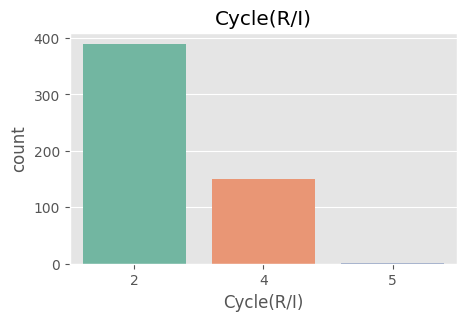

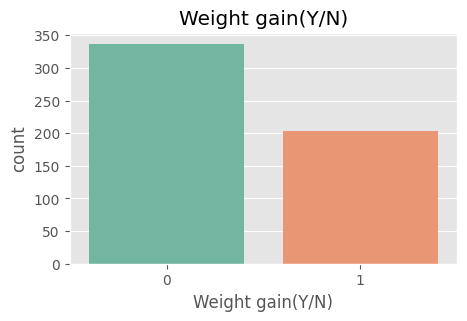

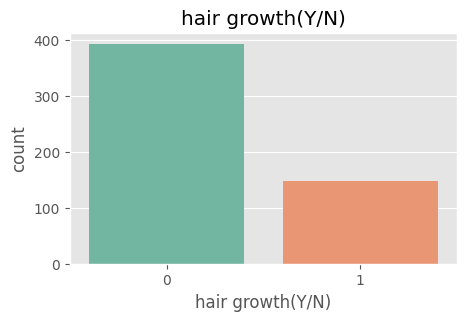

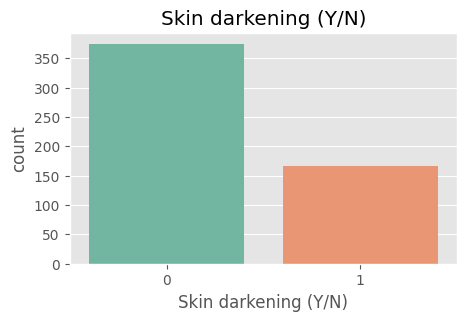

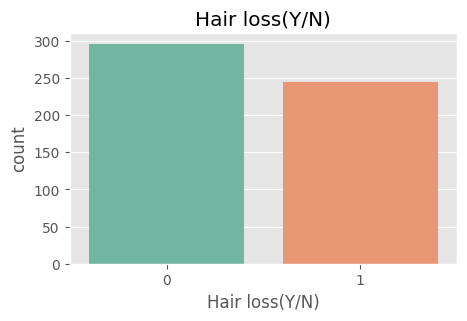

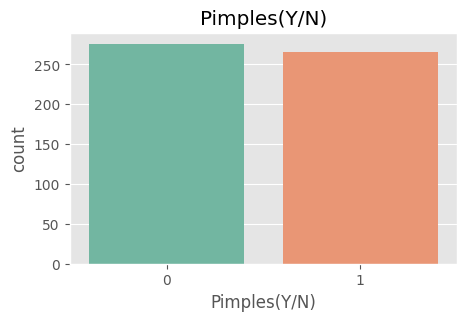

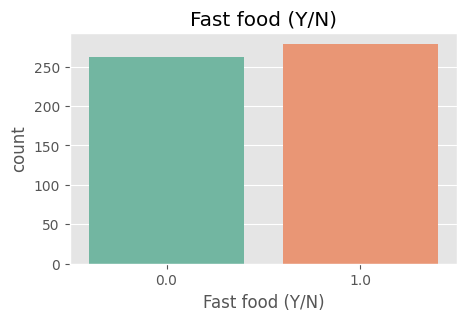

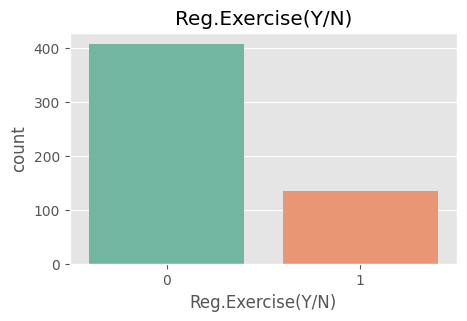

In [29]:
categorical_features = [

'Cycle(R/I)',

'Weight gain(Y/N)',

'hair growth(Y/N)',

'Skin darkening (Y/N)',

'Hair loss(Y/N)',

'Pimples(Y/N)',

'Fast food (Y/N)',

'Reg.Exercise(Y/N)'

]

for feature in categorical_features:

    plt.figure(figsize=(5,3))

    sns.countplot(x=feature,
                  data=df,
                  palette='Set2')

    plt.title(feature)

    plt.show()

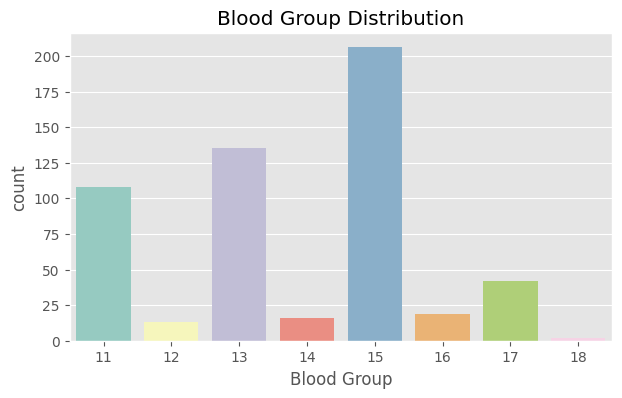

In [30]:
plt.figure(figsize=(7,4))

sns.countplot(x='Blood Group',
              data=df,
              palette='Set3')

plt.title("Blood Group Distribution")

plt.show()

In [31]:
correlation = df.corr(numeric_only=True)['PCOS (Y/N)']

correlation = correlation.sort_values(ascending=False)

print(correlation)

PCOS (Y/N)               1.000000
Follicle No. (R)         0.648327
Follicle No. (L)         0.603346
Skin darkening (Y/N)     0.475733
hair growth(Y/N)         0.464667
Weight gain(Y/N)         0.441047
Cycle(R/I)               0.401644
Fast food (Y/N)          0.376183
Pimples(Y/N)             0.286077
Weight (Kg)              0.211938
Hair loss(Y/N)           0.172879
Waist(inch)              0.164598
Hip(inch)                0.162297
BMI                      0.134635
Avg. F size (L) (mm)     0.132992
Endometrium (mm)         0.106648
Avg. F size (R) (mm)     0.097690
Pulse rate(bpm)          0.091821
Hb(g/dl)                 0.087170
Vit D3 (ng/mL)           0.085494
Height(Cm)               0.068254
Reg.Exercise(Y/N)        0.065337
LH(mIU/mL)               0.063879
FSH/LH                   0.062169
Sl. No                   0.060998
Patient File No.         0.060998
RBS(mg/dl)               0.048922
BP _Diastolic (mmHg)     0.038032
RR (breaths/min)         0.036928
Blood Group   

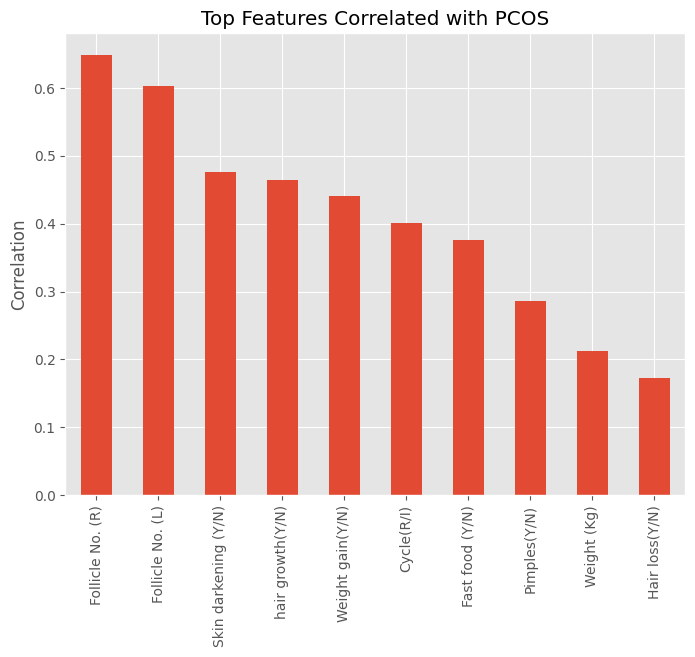

In [32]:
plt.figure(figsize=(8,6))

correlation.drop('PCOS (Y/N)').head(10).plot(kind='bar')

plt.title("Top Features Correlated with PCOS")

plt.ylabel("Correlation")

plt.show()

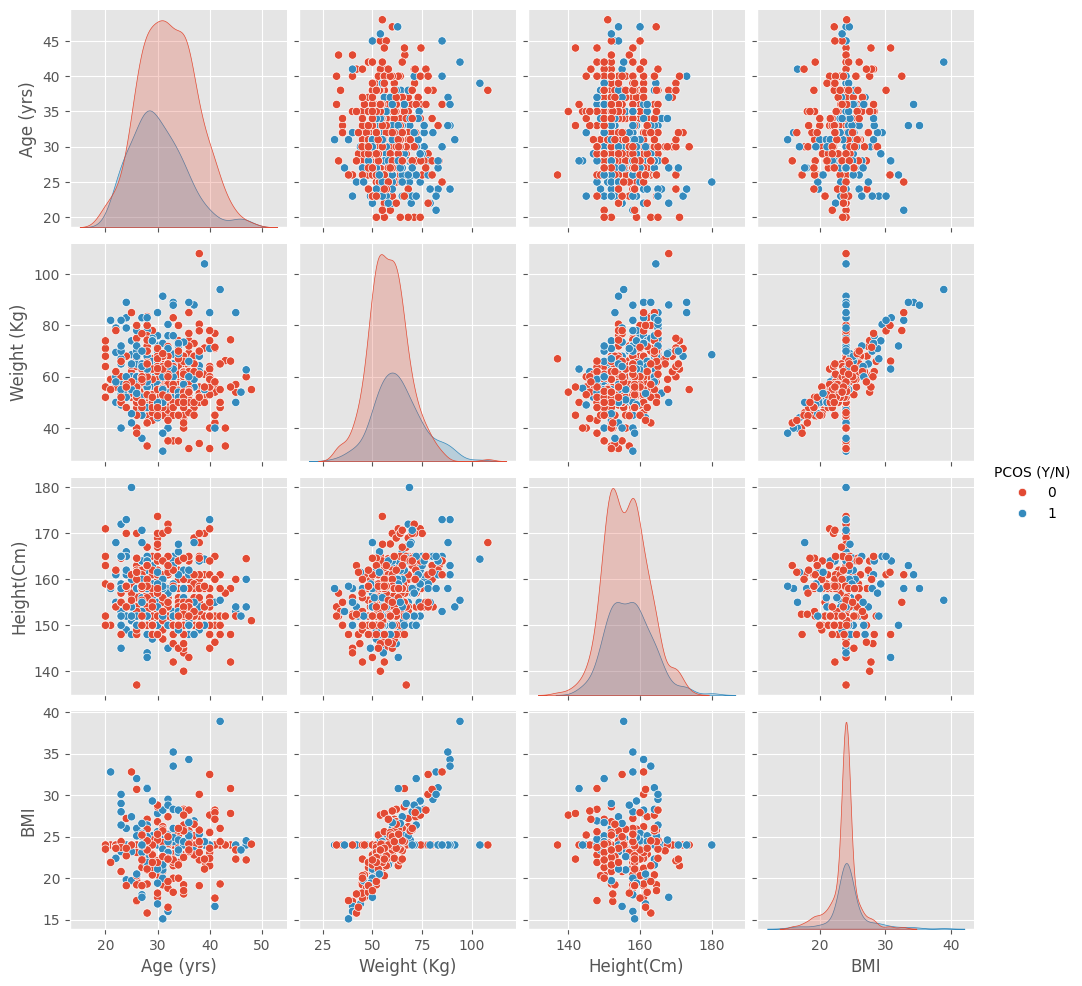

In [33]:
sns.pairplot(df[['Age (yrs)',
                 'Weight (Kg)',
                 'Height(Cm)',
                 'BMI',
                 'PCOS (Y/N)']],
             hue='PCOS (Y/N)')

plt.show()

In [34]:
# Feature Selection:
# Based on the EDA, domain knowledge, and the project objective of enabling early PCOS risk prediction without requiring
# laboratory tests or ultrasound reports, only user-enterable features
# (e.g., age, BMI, menstrual cycle, lifestyle, and symptoms) were selected for model training.
# Clinical and diagnostic features such as hormone levels and follicle counts were intentionally excluded to make the
# web application practical for everyday users.

In [35]:
# =====================================
# Feature Selection
# =====================================

selected_features = [

    'Age (yrs)',
    'Weight (Kg)',
    'Height(Cm)',
    'BMI',
    'Blood Group',
    'Cycle(R/I)',
    'Cycle length(days)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)',
    'PCOS (Y/N)'

]

df = df[selected_features]

print("Selected Features:")
print(df.columns)

print("\nDataset Shape:", df.shape)

Selected Features:
Index(['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group',
       'Cycle(R/I)', 'Cycle length(days)', 'Weight gain(Y/N)',
       'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)',
       'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'PCOS (Y/N)'],
      dtype='object')

Dataset Shape: (541, 15)


In [36]:
df.head()

,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),PCOS (Y/N)
0,28,44.6,152.0,19.3,15,2,5,0,0,0,0,0,1.0,0,0
1,36,65.0,161.5,24.0,15,2,5,0,0,0,0,0,0.0,0,0
2,33,68.8,165.0,24.0,11,2,5,0,0,0,1,1,1.0,0,1
3,37,65.0,148.0,24.0,13,2,5,0,0,0,0,0,0.0,0,0
4,25,52.0,161.0,24.0,11,2,5,0,0,0,1,0,0.0,0,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age (yrs)             541 non-null    int64  
 1   Weight (Kg)           541 non-null    float64
 2   Height(Cm)            541 non-null    float64
 3   BMI                   541 non-null    float64
 4   Blood Group           541 non-null    int64  
 5   Cycle(R/I)            541 non-null    int64  
 6   Cycle length(days)    541 non-null    int64  
 7   Weight gain(Y/N)      541 non-null    int64  
 8   hair growth(Y/N)      541 non-null    int64  
 9   Skin darkening (Y/N)  541 non-null    int64  
 10  Hair loss(Y/N)        541 non-null    int64  
 11  Pimples(Y/N)          541 non-null    int64  
 12  Fast food (Y/N)       541 non-null    float64
 13  Reg.Exercise(Y/N)     541 non-null    int64  
 14  PCOS (Y/N)            541 non-null    int64  
dtypes: float64(4), int64(11

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age (yrs)             541 non-null    int64  
 1   Weight (Kg)           541 non-null    float64
 2   Height(Cm)            541 non-null    float64
 3   BMI                   541 non-null    float64
 4   Blood Group           541 non-null    int64  
 5   Cycle(R/I)            541 non-null    int64  
 6   Cycle length(days)    541 non-null    int64  
 7   Weight gain(Y/N)      541 non-null    int64  
 8   hair growth(Y/N)      541 non-null    int64  
 9   Skin darkening (Y/N)  541 non-null    int64  
 10  Hair loss(Y/N)        541 non-null    int64  
 11  Pimples(Y/N)          541 non-null    int64  
 12  Fast food (Y/N)       541 non-null    float64
 13  Reg.Exercise(Y/N)     541 non-null    int64  
 14  PCOS (Y/N)            541 non-null    int64  
dtypes: float64(4), int64(11

In [39]:
print(df.isnull().sum())

Age (yrs)               0
Weight (Kg)             0
Height(Cm)              0
BMI                     0
Blood Group             0
Cycle(R/I)              0
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         0
Reg.Exercise(Y/N)       0
PCOS (Y/N)              0
dtype: int64


In [40]:
print(df['Cycle(R/I)'].value_counts())

Cycle(R/I)
2    390
4    150
5      1
Name: count, dtype: int64


In [41]:
print(df['Cycle(R/I)'].unique())

[2 4 5]


In [42]:
# ==========================================
# Prepare Features (X) and Target Variable (y)
# ==========================================

X = df.drop('PCOS (Y/N)', axis=1)

y = df['PCOS (Y/N)']

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (541, 14)
Target Shape : (541,)


In [43]:
# ==========================================
# Split Dataset into Training and Testing Sets
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (432, 14)
Testing Samples : (109, 14)


In [44]:
# ==========================================
# Train Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=200,
    random_state=42,
    max_depth=10

)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [45]:
# ==========================================
# Predict on Test Data
# ==========================================

y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 0 1 0 0 0 0]


In [46]:
#MODEL EVALUATION

In [47]:
# ==========================================
# Model Accuracy
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 84.4 %


In [48]:
# ==========================================
# Precision Score
# ==========================================

from sklearn.metrics import precision_score

precision = precision_score(y_test,y_pred)

print("Precision :",round(precision,3))

Precision : 0.806


In [49]:
# ==========================================
# Recall Score
# ==========================================

from sklearn.metrics import recall_score

recall = recall_score(y_test,y_pred)

print("Recall :",round(recall,3))

Recall : 0.694


In [50]:
# ==========================================
# F1 Score
# ==========================================

from sklearn.metrics import f1_score

f1 = f1_score(y_test,y_pred)

print("F1 Score :",round(f1,3))

F1 Score : 0.746


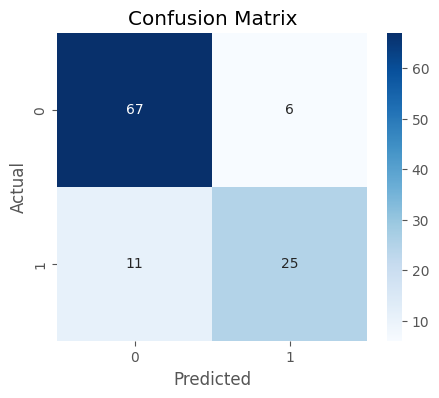

In [51]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [52]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        73
           1       0.81      0.69      0.75        36

    accuracy                           0.84       109
   macro avg       0.83      0.81      0.82       109
weighted avg       0.84      0.84      0.84       109



In [53]:
#FEATURE IMPORTANCE

In [54]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({

'Feature':X.columns,

'Importance':rf_model.feature_importances_

})

importance = importance.sort_values(

by='Importance',

ascending=False

)

print(importance)

                 Feature  Importance
9   Skin darkening (Y/N)    0.122718
0              Age (yrs)    0.101357
1            Weight (Kg)    0.098721
7       Weight gain(Y/N)    0.095307
8       hair growth(Y/N)    0.095083
2             Height(Cm)    0.092673
6     Cycle length(days)    0.090798
3                    BMI    0.066433
5             Cycle(R/I)    0.055425
12       Fast food (Y/N)    0.048068
4            Blood Group    0.043220
11          Pimples(Y/N)    0.040244
13     Reg.Exercise(Y/N)    0.025385
10        Hair loss(Y/N)    0.024567


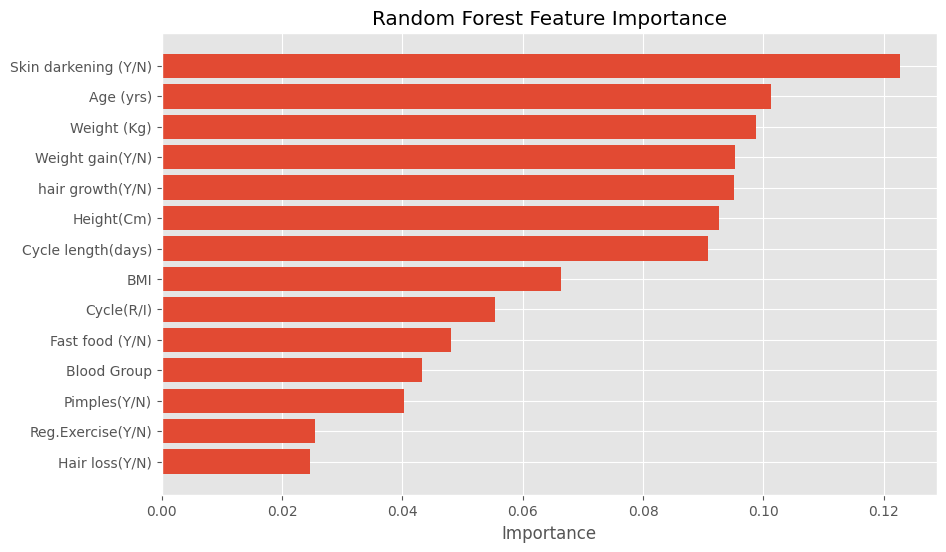

In [55]:
# ==========================================
# Plot Feature Importance
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(

importance['Feature'],

importance['Importance']

)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [56]:
# ==========================================
# Save Trained Model
# ==========================================

import joblib

joblib.dump(rf_model,'pcos_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [57]:
import joblib

loaded_model = joblib.load("pcos_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!
